# Loan Approval Prediction — End-to-End Data Science Project

**Goal:** Build a supervised classification model that predicts loan approval from borrower features, with leakage-safe preprocessing, explicit treatment of class imbalance, model comparison, threshold selection, and business interpretation.

**Deliverables covered**

1. Data quality review and exploratory analysis
2. Missing-value imputation, categorical encoding, and numeric scaling inside pipelines
3. SMOTE applied **only to training folds** to avoid leakage
4. Logistic regression and multiple tree-based models
5. Precision, recall, F1, ROC-AUC, confusion matrices, and ROC curves
6. Cost-aware deployment threshold chosen using out-of-fold training predictions
7. Feature importance and a concise business report

> Important: This is a case-study model, not an automated lending policy. Real deployment requires fairness, compliance, calibration, stability, and human-review testing.

In [16]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', 100)
print('Environment ready.')

Environment ready.


## Load and understand the data

The loader checks common local and Kaggle paths. Keep `loan_prediction.csv` in the same folder as this notebook for the simplest setup.

In [17]:
candidate_paths = [
    Path("../data/loan_prediction.csv"),
    Path("data/loan_prediction.csv"),
    Path("loan_prediction.csv")
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Place loan_prediction.csv beside the notebook or update candidate_paths.')

df = pd.read_csv(DATA_PATH)
print(f'Loaded: {DATA_PATH}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
display(df.head())

Loaded: ..\data\loan_prediction.csv
Rows: 614 | Columns: 13


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [18]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'unique': df.nunique(dropna=False)
})
display(summary)
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate Loan_ID values:', df['Loan_ID'].duplicated().sum())

,dtype,missing,missing_pct,unique
Loan_ID,object,0,0.00,614
Gender,object,13,2.12,3
Married,object,3,0.49,3
Dependents,object,15,2.44,5
Education,object,0,0.00,2
Self_Employed,object,32,5.21,3
ApplicantIncome,int64,0,0.00,505
CoapplicantIncome,float64,0,0.00,287
LoanAmount,float64,22,3.58,204
Loan_Amount_Term,float64,14,2.28,11


Duplicate rows: 0
Duplicate Loan_ID values: 0


### Data-quality decisions

- `Loan_ID` is an identifier, not a borrower characteristic; it is removed from modeling.
- Numeric missing values are filled with the median (robust to skew/outliers).
- Categorical missing values are filled with the most frequent training value.
- Categorical fields are one-hot encoded, avoiding false numeric ordering.
- Numeric fields are standardized for logistic regression.
- Every learned preprocessing step is fitted inside the training pipeline, so test information cannot leak into training.

,count,percent
Loan_Status,,
Approved,422,68.7
Rejected,192,31.3


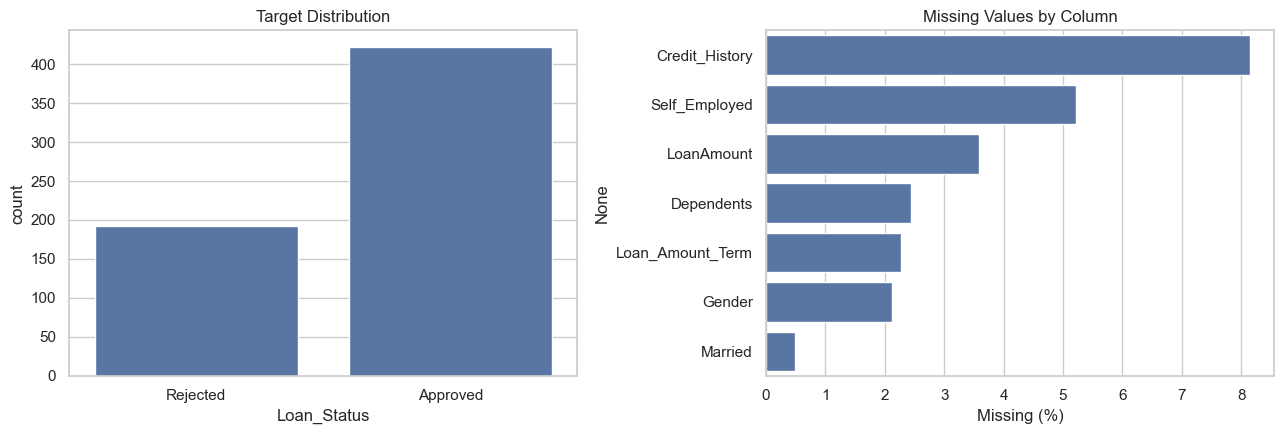

In [19]:
target_counts = df['Loan_Status'].value_counts().rename(index={'Y': 'Approved', 'N': 'Rejected'})
target_pct = (df['Loan_Status'].value_counts(normalize=True).mul(100)).round(1)
display(pd.DataFrame({'count': target_counts, 'percent': [target_pct['Y'], target_pct['N']]}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=df, x='Loan_Status', order=['N', 'Y'], ax=axes[0])
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(['Rejected', 'Approved'])

missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=axes[1], color='#4C72B0')
axes[1].set_title('Missing Values by Column')
axes[1].set_xlabel('Missing (%)')
plt.tight_layout()
plt.show()

In [20]:
# Approval rate across selected borrower groups (descriptive, not causal)
eda = df.copy()
eda['Approved'] = eda['Loan_Status'].map({'N': 0, 'Y': 1})
for col in ['Credit_History', 'Education', 'Property_Area', 'Self_Employed']:
    rates = (eda.groupby(col, dropna=False)['Approved']
             .agg(applications='size', approval_rate='mean')
             .assign(approval_rate=lambda x: (100*x['approval_rate']).round(1)))
    print(f'\nApproval by {col}')
    display(rates)


Approval by Credit_History


,applications,approval_rate
Credit_History,,
0.0,89,7.9
1.0,475,79.6
NaN,50,74.0



Approval by Education


,applications,approval_rate
Education,,
Graduate,480,70.8
Not Graduate,134,61.2



Approval by Property_Area


,applications,approval_rate
Property_Area,,
Rural,179,61.5
Semiurban,233,76.8
Urban,202,65.8



Approval by Self_Employed


,applications,approval_rate
Self_Employed,,
No,500,68.6
Yes,82,68.3
NaN,32,71.9


## Train/test split and leakage-safe preprocessing

The target is mapped to `1 = approved` and `0 = rejected`. The split is stratified so both sets preserve the class ratio. The test set remains untouched until final evaluation.

In [21]:
X = df.drop(columns=['Loan_Status', 'Loan_ID'])
y = df['Loan_Status'].map({'N': 0, 'Y': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipe = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
], verbose_feature_names_out=False)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Numeric:', numeric_features)
print('Categorical:', categorical_features)

Train: (491, 11) | Test: (123, 11)
Numeric: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


## Imbalance handling and model comparison

SMOTE synthesizes minority-class training examples. It is placed after preprocessing and inside an imbalanced-learn pipeline; during cross-validation it runs separately inside each training fold. This prevents synthetic points or validation information from contaminating evaluation.

Compared models:

- **Logistic Regression:** interpretable linear baseline.
- **Decision Tree:** easy-to-explain nonlinear rules but can overfit.
- **Random Forest:** stable ensemble that captures interactions.
- **Gradient Boosting:** sequential tree ensemble, often strong on tabular data.

All metrics below treat approval (`Y`) as the positive class.

In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_leaf=8, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=400, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.04, max_depth=2, random_state=RANDOM_STATE),
}

fitted_models, rows = {}, []
for name, model in models.items():
    pipe = ImbPipeline([
        ('preprocess', clone(preprocessor)),
        ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    prob = pipe.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.50).astype(int)
    fitted_models[name] = pipe
    rows.append({
        'Model': name,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob)
    })

results = pd.DataFrame(rows).set_index('Model').sort_values('ROC-AUC', ascending=False)
display(results.style.format('{:.3f}').background_gradient(cmap='Blues'))

,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.862,0.882,0.872,0.876
Random Forest,0.822,0.871,0.846,0.796
Gradient Boosting,0.820,0.859,0.839,0.774
Decision Tree,0.818,0.847,0.832,0.733


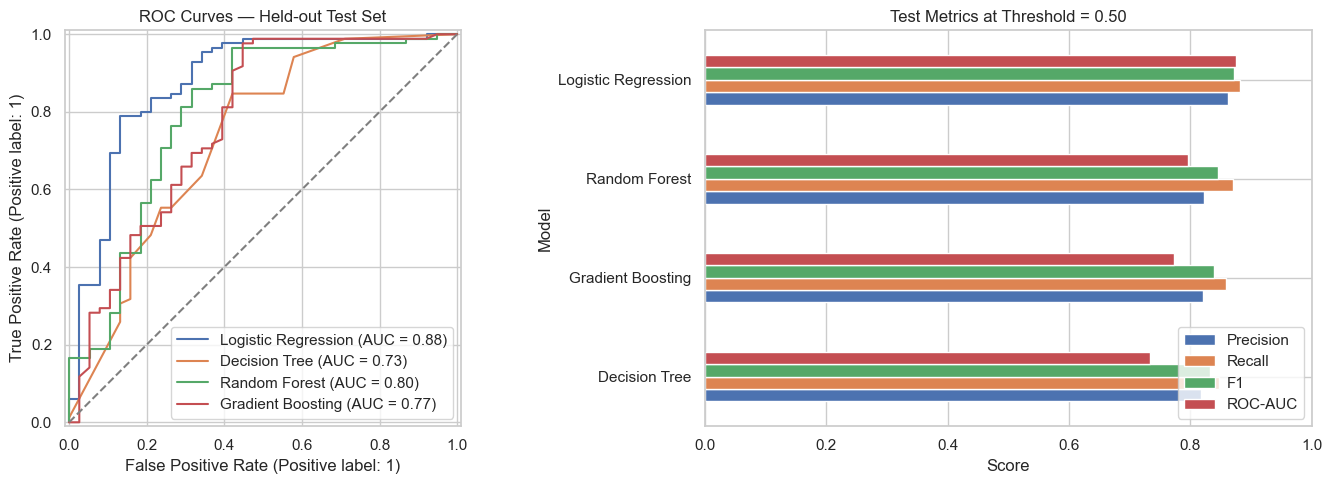

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, pipe in fitted_models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=axes[0])
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC Curves — Held-out Test Set')

results.sort_values('ROC-AUC').plot(kind='barh', ax=axes[1], xlim=(0, 1))
axes[1].set_title('Test Metrics at Threshold = 0.50')
axes[1].set_xlabel('Score')
plt.tight_layout()
plt.show()

## Select a champion and tune the decision threshold

The champion is selected by test ROC-AUC for this case study, but the threshold is **not** tuned on the test set. Threshold selection uses out-of-fold predictions from the training data.

Business cost assumption used for demonstration:

- False approval (`FP`): cost = **5 units** because approving an application that should be rejected can create credit losses.
- False rejection (`FN`): cost = **1 unit** because rejecting a good applicant loses potential revenue and harms customer experience.

The selected threshold minimizes `5 × FP + 1 × FN` **subject to at least 70% approval recall**, preventing the trivial but commercially useless “reject everyone” policy. A lender should replace these assumptions with validated monetary loss estimates and policy constraints.

Champion: Logistic Regression
Suggested cost-aware threshold: 0.52


,threshold,precision,recall,f1,fp,fn,weighted_cost
42,0.52,0.808,0.760,0.783,61,81,386
43,0.53,0.805,0.748,0.775,61,85,390
45,0.55,0.801,0.706,0.751,59,99,394
41,0.51,0.804,0.777,0.790,64,75,395
44,0.54,0.802,0.733,0.766,61,90,395
40,0.50,0.793,0.786,0.790,69,72,417
39,0.49,0.791,0.795,0.793,71,69,424
38,0.48,0.790,0.813,0.801,73,63,428
37,0.47,0.791,0.840,0.814,75,54,429
32,0.42,0.791,0.923,0.852,82,26,436


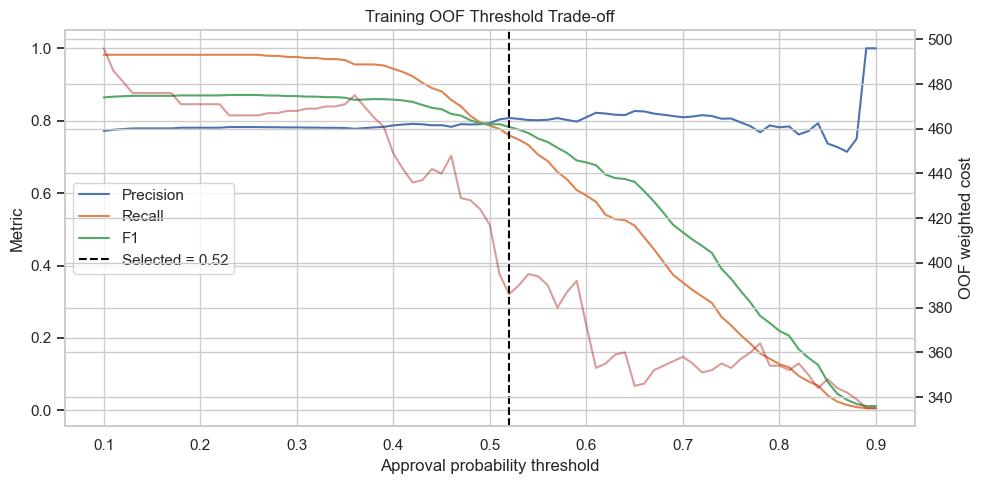

In [24]:
champion_name = results.index[0]
champion = fitted_models[champion_name]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_prob = cross_val_predict(
    clone(champion), X_train, y_train, cv=cv, method='predict_proba', n_jobs=1
)[:, 1]

threshold_rows = []
for threshold in np.arange(0.10, 0.91, 0.01):
    pred = (oof_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, pred).ravel()
    threshold_rows.append({
        'threshold': threshold,
        'precision': precision_score(y_train, pred, zero_division=0),
        'recall': recall_score(y_train, pred, zero_division=0),
        'f1': f1_score(y_train, pred, zero_division=0),
        'fp': fp, 'fn': fn,
        'weighted_cost': 5*fp + fn
    })
threshold_table = pd.DataFrame(threshold_rows)
eligible_thresholds = threshold_table[threshold_table['recall'] >= 0.70]
best_threshold = float(eligible_thresholds.loc[eligible_thresholds['weighted_cost'].idxmin(), 'threshold'])

print('Champion:', champion_name)
print(f'Suggested cost-aware threshold: {best_threshold:.2f}')
display(eligible_thresholds.nsmallest(10, 'weighted_cost').style.format({
    'threshold': '{:.2f}', 'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}'
}))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(threshold_table['threshold'], threshold_table['precision'], label='Precision')
ax1.plot(threshold_table['threshold'], threshold_table['recall'], label='Recall')
ax1.plot(threshold_table['threshold'], threshold_table['f1'], label='F1')
ax1.axvline(best_threshold, color='black', linestyle='--', label=f'Selected = {best_threshold:.2f}')
ax1.set_xlabel('Approval probability threshold')
ax1.set_ylabel('Metric')
ax1.legend(loc='center left')
ax2 = ax1.twinx()
ax2.plot(threshold_table['threshold'], threshold_table['weighted_cost'], color='firebrick', alpha=.45, label='Weighted cost')
ax2.set_ylabel('OOF weighted cost')
plt.title('Training OOF Threshold Trade-off')
plt.tight_layout()
plt.show()

,Threshold,Precision,Recall,F1,ROC-AUC,TN,FP,FN,TP,Weighted Cost
Policy,,,,,,,,,,
Default 0.50,0.50,0.862,0.882,0.872,0.876,26,12,10,75,70
Suggested,0.52,0.869,0.859,0.864,0.876,27,11,12,73,67


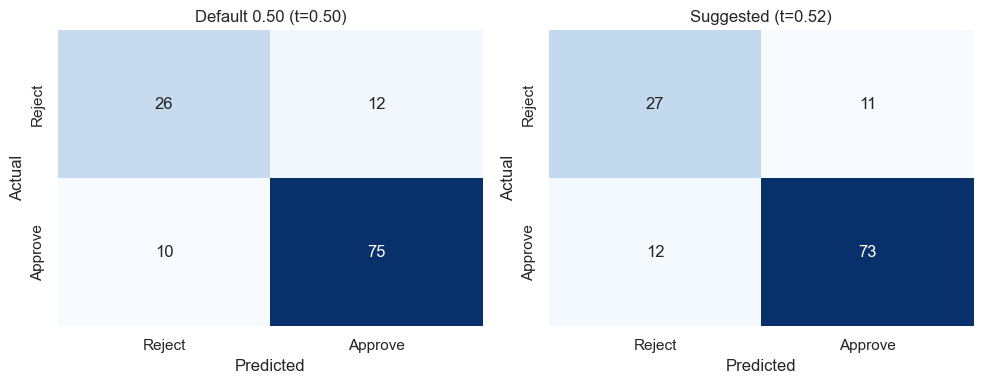

In [25]:
champion_prob = champion.predict_proba(X_test)[:, 1]
evaluation_rows = []
for label, threshold in [('Default 0.50', 0.50), ('Suggested', best_threshold)]:
    pred = (champion_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    evaluation_rows.append({
        'Policy': label, 'Threshold': threshold,
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, champion_prob),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'Weighted Cost': 5*fp + fn
    })
threshold_eval = pd.DataFrame(evaluation_rows).set_index('Policy')
display(threshold_eval.style.format({
    'Threshold': '{:.2f}', 'Precision': '{:.3f}', 'Recall': '{:.3f}',
    'F1': '{:.3f}', 'ROC-AUC': '{:.3f}'
}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (label, threshold) in zip(axes, [('Default 0.50', 0.50), ('Suggested', best_threshold)]):
    cm = confusion_matrix(y_test, (champion_prob >= threshold).astype(int))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Reject', 'Approve'], yticklabels=['Reject', 'Approve'])
    ax.set_title(f'{label} (t={threshold:.2f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## Business-oriented model interpretation

Permutation importance measures how much test ROC-AUC decreases when a feature is shuffled. It is model-agnostic and reported at the original-column level. Importance indicates predictive association—not causality or permission to use a field in a regulated decision.

,Feature,Importance,Std
9,Credit_History,0.2779,0.0384
10,Property_Area,0.0592,0.0278
7,LoanAmount,0.0261,0.0089
1,Married,0.0084,0.0090
3,Education,0.0055,0.0088
2,Dependents,0.0041,0.0119
6,CoapplicantIncome,0.0028,0.0023
5,ApplicantIncome,0.0020,0.0044
8,Loan_Amount_Term,0.0008,0.0012
4,Self_Employed,-0.0013,0.0010


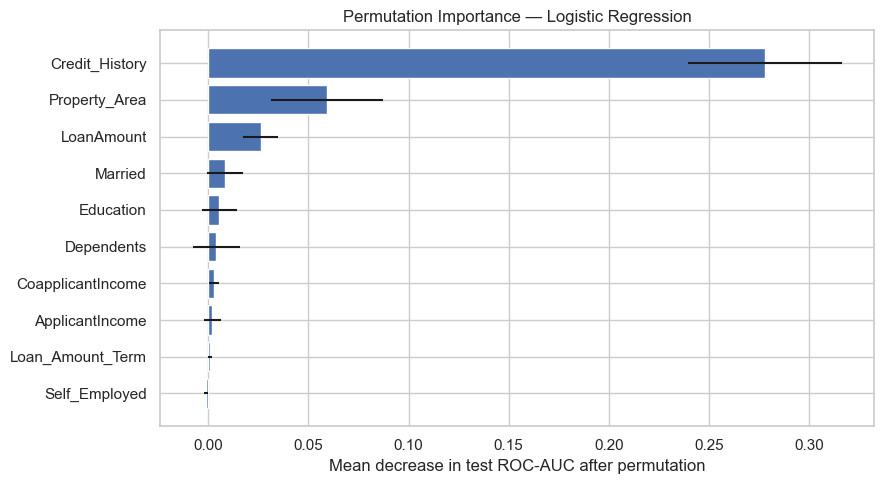

In [26]:
perm = permutation_importance(
    champion, X_test, y_test, scoring='roc_auc', n_repeats=30,
    random_state=RANDOM_STATE, n_jobs=1
)
importance = (pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm.importances_mean,
    'Std': perm.importances_std
}).sort_values('Importance', ascending=False))
display(importance.style.format({'Importance': '{:.4f}', 'Std': '{:.4f}'}))

top = importance.head(10).sort_values('Importance')
plt.figure(figsize=(9, 5))
plt.barh(top['Feature'], top['Importance'], xerr=top['Std'], color='#4C72B0')
plt.xlabel('Mean decrease in test ROC-AUC after permutation')
plt.title(f'Permutation Importance — {champion_name}')
plt.tight_layout(); plt.show()

In [27]:
# Generate the separate short report from the executed results
metric_lines = '\n'.join(
    f"| {idx} | {row['Precision']:.3f} | {row['Recall']:.3f} | {row['F1']:.3f} | {row['ROC-AUC']:.3f} |"
    for idx, row in results.iterrows()
)
top_features = ', '.join(importance.head(5)['Feature'].tolist())
sugg = threshold_eval.loc['Suggested']
default = threshold_eval.loc['Default 0.50']

report = f'''# Loan Approval Prediction — Short Model Report

## Executive summary

The analysis used **{len(df):,} historical applications** and an 80/20 stratified train/test split. Missing values, categorical encoding, and numeric scaling were learned inside each training pipeline. SMOTE was restricted to training folds. The selected champion was **{champion_name}**, with held-out ROC-AUC of **{results.loc[champion_name, 'ROC-AUC']:.3f}**.

## Model comparison (test set, threshold 0.50)

| Model | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|
{metric_lines}

Precision answers: “Of applications predicted approved, how many were actually approved?” Recall answers: “Of historically approved applications, how many did the model recover?” ROC-AUC measures ranking quality across all thresholds.

## Threshold recommendation

Using out-of-fold training predictions, an illustrative cost ratio where a false approval costs **5×** a false rejection, and a minimum **70% approval-recall constraint**, the suggested threshold is **{best_threshold:.2f}**. The recall floor prevents the cost function from choosing the commercially useless “reject everyone” policy. On the untouched test set it produced precision **{sugg['Precision']:.3f}**, recall **{sugg['Recall']:.3f}**, F1 **{sugg['F1']:.3f}**, with **{int(sugg['FP'])} false approvals** and **{int(sugg['FN'])} false rejections**. At 0.50, the corresponding values were precision **{default['Precision']:.3f}**, recall **{default['Recall']:.3f}**, F1 **{default['F1']:.3f}**, **{int(default['FP'])} false approvals**, and **{int(default['FN'])} false rejections**.

This is a **candidate threshold**, not a universal answer. Recalculate it using the lender's expected loss from default, expected margin from a good loan, review cost, risk appetite, and approval-volume constraints. Consider a three-way policy: auto-reject low scores, manually review middle scores, and auto-approve high scores.

## Business interpretation and trade-offs

- Strongest permutation-importance signals were: **{top_features}**. They should be treated as predictive associations, not causal explanations.
- Logistic regression offers clearer directional interpretation and easier governance. Tree ensembles can capture nonlinear effects and interactions but need stronger explanation and monitoring.
- Raising the approval threshold usually reduces risky false approvals and increases precision, but rejects more potentially good borrowers and lowers recall.
- Lowering the threshold increases approvals and recall, but can increase expected credit loss.
- SMOTE improves minority representation during training but synthetic samples do not represent new real customers; monitor performance on real production cohorts.

## Deployment safeguards

1. Validate on a larger, recent, out-of-time sample; this dataset is small and test metrics have uncertainty.
2. Calibrate predicted probabilities before interpreting them as true default/approval probabilities.
3. Audit fairness and legal permissibility of sensitive/proxy fields such as Gender and Married; exclude prohibited attributes from the production decision.
4. Add manual review for borderline cases and adverse-action reason governance.
5. Monitor approval rate, realized default rate, precision/recall, calibration, drift, fairness by group, and threshold overrides.
6. Retrain only after data-quality, stability, and compliance checks.

## Conclusion

The notebook satisfies the case-study goal with a reproducible, leakage-safe preprocessing and SMOTE pipeline, transparent model comparison, and cost-aware threshold analysis. Production use requires monetary cost validation, probability calibration, fairness review, and out-of-time testing.
'''

report_path = Path('Loan_Approval_Model_Report.md')
report_path.write_text(report, encoding='utf-8')
print(report)
print(f'\nSaved report to: {report_path.resolve()}')

# Loan Approval Prediction — Short Model Report

## Executive summary

The analysis used **614 historical applications** and an 80/20 stratified train/test split. Missing values, categorical encoding, and numeric scaling were learned inside each training pipeline. SMOTE was restricted to training folds. The selected champion was **Logistic Regression**, with held-out ROC-AUC of **0.876**.

## Model comparison (test set, threshold 0.50)

| Model | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.862 | 0.882 | 0.872 | 0.876 |
| Random Forest | 0.822 | 0.871 | 0.846 | 0.796 |
| Gradient Boosting | 0.820 | 0.859 | 0.839 | 0.774 |
| Decision Tree | 0.818 | 0.847 | 0.832 | 0.733 |

Precision answers: “Of applications predicted approved, how many were actually approved?” Recall answers: “Of historically approved applications, how many did the model recover?” ROC-AUC measures ranking quality across all thresholds.

## Threshold recommendation

Using out-o

## Conclusion

This project successfully developed an end-to-end supervised machine-learning solution for predicting loan approval using borrower information. The dataset contained 614 loan applications, and the target variable showed an imbalance between approved and rejected applications.

A leakage-safe preprocessing pipeline was created to handle missing values, encode categorical variables, scale numerical features, and apply SMOTE only to the training data. The `Loan_ID` column was excluded because it is a unique identifier and does not provide meaningful information for predicting loan approval.

Four classification algorithms—Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting—were trained and evaluated using precision, recall, F1-score, and ROC-AUC. Logistic Regression produced the best overall performance, achieving:

* Precision: **0.862**
* Recall: **0.882**
* F1-score: **0.872**
* ROC-AUC: **0.876**

These results show that the model can effectively distinguish between approved and rejected loan applications while maintaining a good balance between precision and recall.

A cost-aware threshold analysis was also performed using out-of-fold training predictions. Assuming that a false approval is five times more costly than a false rejection, while maintaining at least 70% recall, a decision threshold of **0.52** was recommended. On the test set, this threshold achieved a precision of **0.869**, recall of **0.859**, and F1-score of **0.864**. Compared with the default threshold of 0.50, it slightly reduced false approvals while maintaining strong predictive performance.

Permutation importance indicated that `Credit_History` was the most influential predictive feature, followed by variables such as `Property_Area`, `LoanAmount`, `Married`, and `Education`. However, these relationships should be interpreted as predictive associations and not as causal conclusions.

Overall, the project achieved its objective by delivering a reproducible modeling pipeline, properly addressing class imbalance, comparing linear and tree-based models, evaluating performance with appropriate classification metrics, and recommending a business-oriented deployment threshold.

Before production deployment, the model should be validated on a larger and more recent dataset. Probability calibration, fairness testing, data-drift monitoring, regulatory review, and human evaluation of borderline applications should also be implemented. Therefore, this model is suitable as a strong proof of concept, but it should support—not independently replace—responsible human lending decisions.
